# Observation scoring with an ODE-flow Cuthbert EnKF

This notebook combines the observation-scoring workflow from [Part 12: Observation scoring with filters](../tutorials/gentle_intro/12_observation_scoring_with_filters.ipynb) with the deterministic filtering pattern from [Filtering of deterministic continuous-time processes](filtering_deterministic_processes.ipynb).

We simulate a deterministic Lorenz–63 trajectory, turn its numerical ODE flow into a discrete-time transition, filter with the Cuthbert ensemble Kalman filter, and score the one-step-ahead predictive observation distributions through the scoring-rules API. A well-specified model with $\rho=28$ is compared with a misspecified model using $\rho=24$ under identical common random numbers.

The essential handler nesting is:

```python
with Evaluation(observation_scoring_config=scoring_config):
    with Filter(filter_config=enkf_config):
        with Discretizer(flow_config):
            result = dsx.condition(...)

scores = result.evaluation_result.observation_scores
```

## Forecast alignment and the first observation

Scoring requires the forecast before each observation update. Given observations $(y_0,\ldots,y_{T-1})$ at $(t_0,\ldots,t_{T-1})$, the entry at index $k$ must represent $p(y_k\mid y_{0:k-1})$.

- At $k=0$, the predicted state ensemble is sampled from the initial-state prior, passed through the configured pre-update inflation, and projected into observation space; there is no ODE transition before the first observation.
- At $k\geq 1$, each member of the filtered ensemble at $t_{k-1}$ is integrated to $t_k$, then projected into observation space before $y_k$ is assimilated.
- Cuthbert internally returns a leading dummy state, but Dynestyx removes it while constructing the canonical result. The returned forecast, observation, and score arrays all have length $T$ and must not be shifted again.

Later we verify this contract from shapes, time stamps, the first score, and the equality between the summed Gaussian log score and the EnKF marginal log-likelihood.

In [ ]:
import os
from pathlib import Path

import diffrax as dfx
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
from IPython.display import Markdown, display
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    Evaluation,
    LinearGaussianObservation,
    ODESimulator,
    ODESimulatorConfig,
)
from dynestyx.discretizers import Discretizer, ODEFlowConfig
from dynestyx.evaluation.configs import ObservationScoringConfig
from dynestyx.evaluation.scoring import (
    DawidSebastianiScore,
    EnergyScore,
    GaussianLogProbScore,
    ObservationWiseCRPSScore,
)
from dynestyx.inference.configs.filter import EnKFConfig
from dynestyx.inference.filters import Filter

STATE_DIM = 3
TRUE_RHO = 28.0
MISSPECIFIED_RHO = 24.0
OBS_DT = 0.05
OBS_BURN_IN_TIME = 100.0
OBS_FINAL_TIME = 15.0
ANALYSIS_FINAL_TIME = 8.0
N_ENSEMBLE = 30
ENKF_INFLATION_DELTA = 0.1
FULL_SIM_TIMES = jnp.arange(
    0.0,
    OBS_BURN_IN_TIME + OBS_FINAL_TIME + 1e-9,
    OBS_DT,
)

MODEL_SPECS = [
    ("well_specified", r"$\rho=28$ (well specified)", TRUE_RHO, "#009E73"),
    ("misspecified", r"$\rho=24$ (misspecified)", MISSPECIFIED_RHO, "#E69F00"),
]
TRUTH_COLOR = "#222222"
OBS_COLOR = "#5F5F5F"

METRIC_SPECS = [
    ("gaussian_log_prob", "Gaussian log-probability", "higher"),
    ("dawid_sebastiani", "Dawid–Sebastiani", "lower"),
    ("observation_wise_crps", "Observation-wise CRPS", "lower"),
    ("energy_score", "Energy score", "lower"),
]

mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.9,
    "lines.linewidth": 2.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
})

default_figure_dir = (
    Path("docs/deep_dives/figures/observation_scoring_with_cuthbert_enkf")
    if Path("docs").exists()
    else Path("figures/observation_scoring_with_cuthbert_enkf")
)
FIGURE_DIR = Path(os.environ.get("DYNESTYX_FIGURE_DIR", default_figure_dir))
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")


In [2]:
ode_config = ODESimulatorConfig(
    solver=dfx.Tsit5(),
    stepsize_controller=dfx.PIDController(rtol=1e-6, atol=1e-8),
    adjoint=dfx.RecursiveCheckpointAdjoint(),
    dt0=1e-2,
    max_steps=100_000,
    throw=False,
)


def build_l63_dynamics(rho):
    rho = jnp.asarray(rho)

    def drift(x, u, t):
        return jnp.array([
            10.0 * (x[1] - x[0]),
            x[0] * (rho - x[2]) - x[1],
            x[0] * x[1] - (8.0 / 3.0) * x[2],
        ])

    return DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(STATE_DIM),
            covariance_matrix=20.0**2 * jnp.eye(STATE_DIM),
        ),
        state_evolution=ContinuousTimeStateEvolution(drift=drift),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]),
            R=jnp.array([[1.0]]),
        ),
    )


def simulation_model(predict_times=None):
    return dsx.sample(
        "f",
        build_l63_dynamics(TRUE_RHO),
        predict_times=predict_times,
    )


def simulate_dataset(key=jr.PRNGKey(0)):
    predictive = Predictive(
        simulation_model,
        num_samples=1,
        exclude_deterministic=False,
    )
    with ODESimulator(simulator_config=ode_config):
        synthetic = predictive(key, predict_times=FULL_SIM_TIMES)

    full_times = synthetic["f_times"][0, 0]
    full_states = synthetic["f_states"][0, 0]
    full_observations = synthetic["f_observations"][0, 0]
    keep = full_times >= OBS_BURN_IN_TIME - 1e-12
    return {
        "times": full_times[keep] - OBS_BURN_IN_TIME,
        "states": full_states[keep],
        "observations": full_observations[keep],
    }

## Generate a deterministic, partially observed trajectory

The state path is deterministic conditional on its sampled initial condition, while observations of the first state coordinate retain unit-variance Gaussian noise. We discard a long burn-in and use the first eight retained time units for scoring.

observations used for scoring: 161
observation shape per time: (1,)


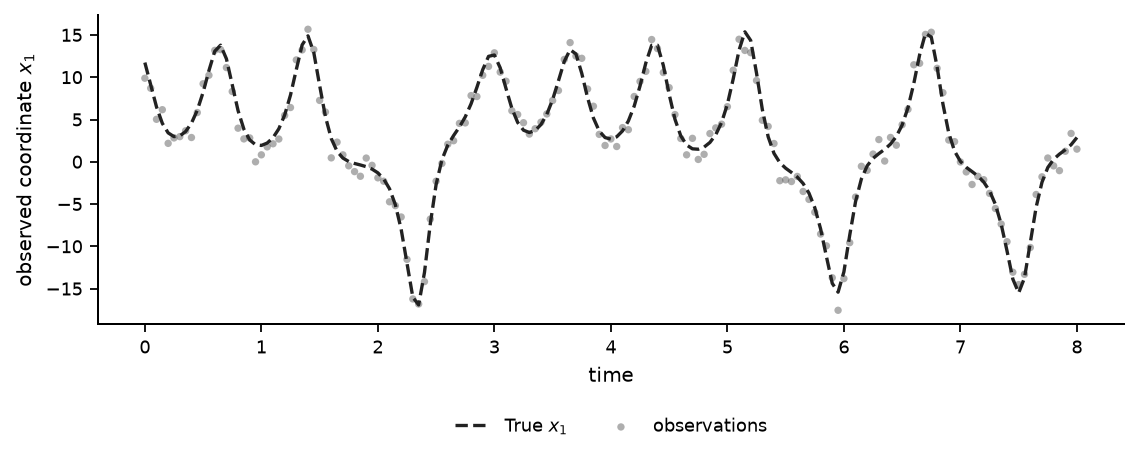

In [ ]:
dataset = simulate_dataset()
analysis_mask = dataset["times"] <= ANALYSIS_FINAL_TIME + 1e-12
obs_times = dataset["times"][analysis_mask]
obs_values = dataset["observations"][analysis_mask]
true_states = dataset["states"][analysis_mask]

print(f"observations used for scoring: {obs_values.shape[0]}")
print(f"observation shape per time: {obs_values.shape[1:]}")

fig, ax = plt.subplots(figsize=(7.2, 2.8))
ax.plot(
    np.asarray(obs_times),
    np.asarray(true_states[:, 0]),
    color=TRUTH_COLOR,
    linestyle="--",
    linewidth=1.5,
    label=r"True $x_1$",
)
ax.scatter(
    np.asarray(obs_times),
    np.asarray(obs_values[:, 0]),
    s=11,
    color=OBS_COLOR,
    alpha=0.50,
    edgecolors="none",
    label="observations",
)
ax.set_xlabel("time")
ax.set_ylabel(r"observed coordinate $x_1$")
despine(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2)
fig.subplots_adjust(left=0.10, right=0.99, top=0.97, bottom=0.28)
plt.show()

## Configure the scoring rules and ODE-flow EnKF

We use four proper scoring rules. Gaussian log-probability is better when higher; Dawid–Sebastiani, componentwise CRPS, and energy score are better when lower. See the scoring tutorial linked above for their definitions and interpretation.

`sample_source="auto"` is important here. The Cuthbert EnKF provides the stored forecast state ensemble, which Dynestyx projects through the observation mean function, together with the observation-noise covariance. Gaussian-moment rules use the resulting total predictive covariance. For the energy score, automatic routing adds reproducible observation-noise draws to the projected ensemble because Cuthbert does not return a noise-perturbed observation ensemble.

`include_predicted_observations=True` requests the incoming forecast ensemble needed for these canonical predictions. The ODE flow uses `jitter_scale=0`, so every ensemble member follows the exact deterministic transition represented by the numerical solver; multiplicative inflation combats ensemble collapse without changing the transition model.

In [4]:
scoring_config = ObservationScoringConfig(
    rules=(
        GaussianLogProbScore(),
        DawidSebastianiScore(),
        ObservationWiseCRPSScore(),
        EnergyScore(beta=1.0),
    ),
    sample_source="auto",
    sample_seed=17,
)

enkf_config = EnKFConfig(
    n_particles=N_ENSEMBLE,
    crn_seed=jr.PRNGKey(31415),
    inflation_delta=ENKF_INFLATION_DELTA,
    filter_source="cuthbert",
    include_predicted_observations=True,
    warn=False,
)

flow_config = ODEFlowConfig(
    simulator_config=ode_config,
    jitter_scale=0.0,
)

scoring_config, enkf_config, flow_config

(ObservationScoringConfig(rules=(GaussianLogProbScore(name=None), DawidSebastianiScore(name=None), ObservationWiseCRPSScore(name=None, min_variance=1e-12), EnergyScore(name=None, beta=1.0, n_samples=None, vectorized_pairwise=True)), record_as_numpyro_sites=True, sample_source='auto', sample_seed=17),
 EnKFConfig(extra_filter_kwargs={}, warn=False, record_filtered_states_mean=None, record_filtered_states_cov=None, record_filtered_states_cov_diag=None, record_filtered_particles=None, record_filtered_log_weights=None, record_filtered_states_chol_cov=None, include_predicted_observations=True, record_predicted_observations_mean=True, record_predicted_observations_cov=True, record_predicted_observations_ensemble=True, record_max_elems=100000, filter_source='cuthbert', cov_rescaling=None, crn_seed=Array([    0, 31415], dtype=uint32), n_particles=30, perturb_measurements=None, inflation_delta=0.1),
 ODEFlowConfig(simulator_config=ODESimulatorConfig(solver=Tsit5(), adjoint=RecursiveCheckpointAd

## Run scored filters through the direct result API

Both runs reuse the same observations and EnKF common-random-number seed. This makes the effect of changing $\rho$ easier to distinguish from finite-ensemble randomness.

In [5]:
def run_scored_filter(rho):
    with Evaluation(observation_scoring_config=scoring_config):
        with Filter(filter_config=enkf_config):
            with Discretizer(flow_config):
                return dsx.condition(
                    "f",
                    build_l63_dynamics(rho),
                    obs_times=obs_times,
                    obs_values=obs_values,
                )


scored_runs = {
    key: run_scored_filter(rho)
    for key, _, rho, _ in MODEL_SPECS
}

for key, label, _, _ in MODEL_SPECS:
    print(f"{label:30s} marginal log-likelihood = {float(scored_runs[key].marginal_loglik):.3f}")

$\rho=28$ (well specified)     marginal log-likelihood = -260.060
$\rho=24$ (misspecified)       marginal log-likelihood = -299.736


## Verify the one-step-ahead alignment

These checks are part of the example, not merely defensive bookkeeping. They verify that every observation is paired with its pre-update forecast, including the prior forecast at the first time, and that no Cuthbert dummy entry survives in the public result.

In [6]:
def check_alignment(key, label, result):
    predictions = result.predicted_observations
    scores = result.evaluation_result.observation_scores
    states = result.states
    n_times = obs_times.shape[0]

    assert predictions is not None
    assert result.evaluation_result is not None
    assert states.predicted_ensemble.shape == (n_times, N_ENSEMBLE, STATE_DIM)
    assert predictions.ensemble.shape == (n_times, N_ENSEMBLE, 1)
    assert predictions.mean.shape == (n_times, 1)
    assert predictions.cov.shape == (n_times, 1, 1)
    assert predictions.obs_cov.shape == (n_times, 1, 1)
    assert predictions.noise_cov.shape == (n_times, 1, 1)
    assert predictions.obs_ensemble is None

    np.testing.assert_allclose(
        np.asarray(states.model_inputs.time),
        np.asarray(obs_times),
        rtol=0.0,
        atol=0.0,
    )
    first_step_flags = np.asarray(states.model_inputs.is_first_step)
    assert first_step_flags[0]
    assert not first_step_flags[1:].any()

    np.testing.assert_allclose(
        np.asarray(predictions.ensemble),
        np.asarray(states.predicted_ensemble[..., 0:1]),
        rtol=1e-12,
        atol=1e-12,
    )
    for metric_name, _, _ in METRIC_SPECS:
        assert np.asarray(scores[metric_name]).shape == (n_times, 1)

    manual_first_log_score = dist.MultivariateNormal(
        loc=predictions.mean[0],
        covariance_matrix=predictions.obs_cov[0],
    ).log_prob(obs_values[0])
    np.testing.assert_allclose(
        np.asarray(scores["gaussian_log_prob"][0, 0]),
        np.asarray(manual_first_log_score),
        rtol=1e-6,
        atol=1e-6,
    )

    summed_log_score = float(np.asarray(scores["gaussian_log_prob"]).sum())
    marginal_loglik = float(np.asarray(result.marginal_loglik))
    np.testing.assert_allclose(
        summed_log_score,
        marginal_loglik,
        rtol=1e-6,
        atol=1e-6,
    )
    return label, summed_log_score, marginal_loglik, abs(summed_log_score - marginal_loglik)


alignment_rows = [
    check_alignment(key, label, scored_runs[key])
    for key, label, _, _ in MODEL_SPECS
]

alignment_table = [
    "| Model | Sum of Gaussian log scores | Marginal log-likelihood | Absolute difference |",
    "|---|---:|---:|---:|",
]
for label, score_sum, marginal_loglik, difference in alignment_rows:
    alignment_table.append(
        f"| {label} | {score_sum:.6f} | {marginal_loglik:.6f} | {difference:.2e} |"
    )
display(Markdown("\n".join(alignment_table)))

| Model | Sum of Gaussian log scores | Marginal log-likelihood | Absolute difference |
|---|---:|---:|---:|
| $\rho=28$ (well specified) | -260.060423 | -260.060423 | 0.00e+00 |
| $\rho=24$ (misspecified) | -299.735723 | -299.735723 | 0.00e+00 |

## Inspect the one-step predictive observation distributions

The bands below use the total predictive observation covariance, including observation noise. Every mean and interval is plotted at the time of the observation it predicts; an accidental one-step shift would be visible here and would also fail the log-likelihood identity above.

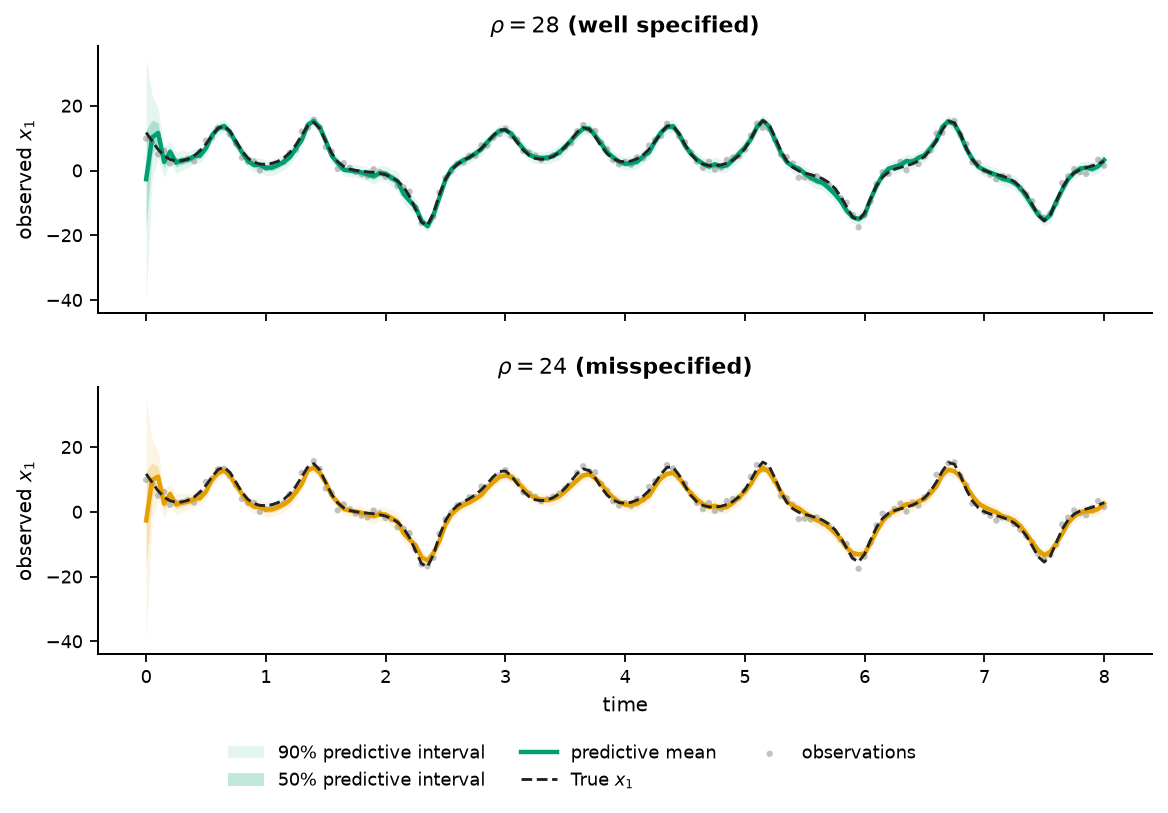

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(7.4, 5.0), sharex=True)
times_np = np.asarray(obs_times)
truth_np = np.asarray(true_states[:, 0])
observations_np = np.asarray(obs_values[:, 0])

for ax, (key, label, _, color) in zip(axes, MODEL_SPECS, strict=True):
    predictions = scored_runs[key].predicted_observations
    mean = np.asarray(predictions.mean[:, 0])
    std = np.sqrt(np.maximum(np.asarray(predictions.obs_cov[:, 0, 0]), 0.0))

    ax.fill_between(
        times_np,
        mean - 1.64485 * std,
        mean + 1.64485 * std,
        color=color,
        alpha=0.10,
        linewidth=0,
        label="90% predictive interval",
    )
    ax.fill_between(
        times_np,
        mean - 0.67449 * std,
        mean + 0.67449 * std,
        color=color,
        alpha=0.24,
        linewidth=0,
        label="50% predictive interval",
    )
    ax.plot(times_np, mean, color=color, linewidth=2.0, label="predictive mean")
    ax.plot(
        times_np,
        truth_np,
        color=TRUTH_COLOR,
        linestyle="--",
        linewidth=1.3,
        label=r"True $x_1$",
    )
    ax.scatter(
        times_np,
        observations_np,
        s=8,
        color=OBS_COLOR,
        alpha=0.38,
        edgecolors="none",
        label="observations",
    )
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel(r"observed $x_1$")
    despine(ax)

axes[-1].set_xlabel("time")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=3)
fig.subplots_adjust(left=0.10, right=0.99, top=0.94, bottom=0.18, hspace=0.28)
plt.show()

## Compare scores through time

The table preserves each rule's direction of improvement. The plots retain the per-time values, making it possible to see whether a difference in temporal averages comes from sustained predictive quality or a few severe misses.

| Score | Direction | $\rho=28$ mean | $\rho=24$ mean |
|---|:---:|---:|---:|
| Gaussian log-probability | higher | -1.6153 | -1.8617 |
| Dawid–Sebastiani | lower | 1.3927 | 1.8855 |
| Observation-wise CRPS | lower | 0.7467 | 0.8939 |
| Energy score | lower | 0.7736 | 0.9193 |

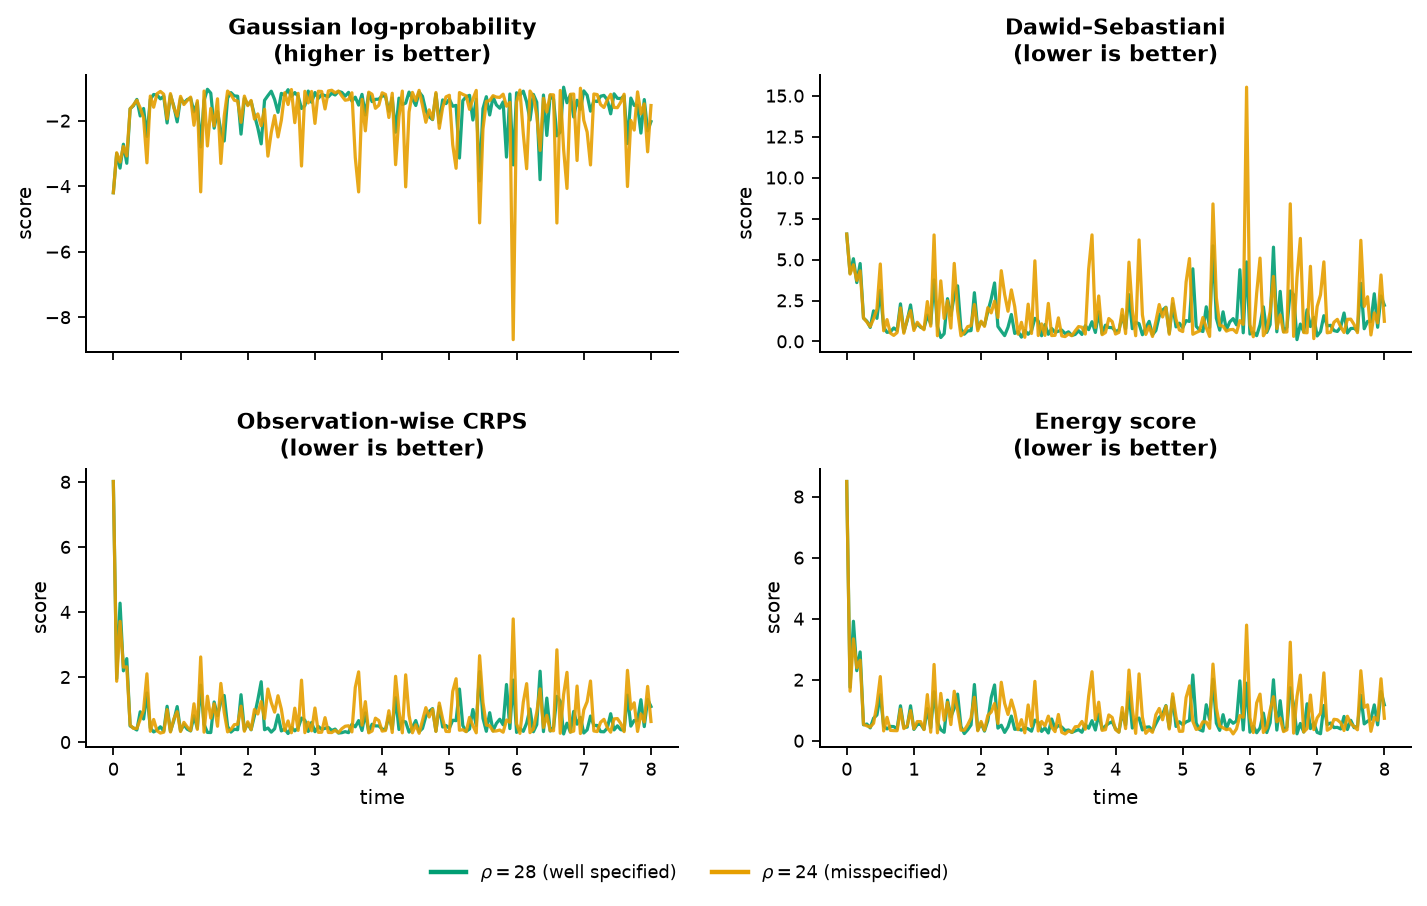

In [ ]:
summary_table = [
    "| Score | Direction | $\\rho=28$ mean | $\\rho=24$ mean |",
    "|---|:---:|---:|---:|",
]
for metric_name, metric_label, objective in METRIC_SPECS:
    means = []
    for key, _, _, _ in MODEL_SPECS:
        values = np.asarray(
            scored_runs[key].evaluation_result.observation_scores[metric_name]
        )
        means.append(float(values.mean()))
    summary_table.append(
        f"| {metric_label} | {objective} | {means[0]:.4f} | {means[1]:.4f} |"
    )
display(Markdown("\n".join(summary_table)))

fig, axes = plt.subplots(2, 2, figsize=(9.2, 5.6), sharex=True)
for ax, (metric_name, metric_label, objective) in zip(
    axes.ravel(),
    METRIC_SPECS,
    strict=True,
):
    for key, label, _, color in MODEL_SPECS:
        values = np.asarray(
            scored_runs[key].evaluation_result.observation_scores[metric_name]
        )[:, 0]
        ax.plot(times_np, values, color=color, linewidth=1.45, alpha=0.90, label=label)
    ax.set_title(f"{metric_label}\n({objective} is better)", fontweight="bold")
    ax.set_ylabel("score")
    despine(ax)

for ax in axes[-1]:
    ax.set_xlabel("time")

score_handles = [
    mpl.lines.Line2D([], [], color=color, linewidth=2.0, label=label)
    for _, label, _, color in MODEL_SPECS
]
fig.legend(
    handles=score_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=2,
)
fig.subplots_adjust(left=0.09, right=0.99, top=0.91, bottom=0.16, hspace=0.42, wspace=0.24)
plt.show()

## Takeaways

- Observation scoring composes with deterministic ODE models by placing an `ODEFlowConfig` discretizer inside a Cuthbert `EnKFConfig` filter and an `Evaluation` handler outside both.
- `include_predicted_observations=True` is sufficient to collect the pre-update Cuthbert forecast ensemble; recording NumPyro sites is a separate concern.
- The first returned prediction is the inflated pre-update prior forecast for the first observation, with no ODE transition. Dynestyx has already removed Cuthbert's dummy state, so score and prediction arrays should never be shifted again.
- `sample_source="auto"` uses Gaussian moments for moment-based rules and the projected forecast ensemble plus observation noise for the energy score.
- Keeping per-time scores makes model misspecification easier to diagnose than a marginal log-likelihood or temporal average alone.

For broader filter and parameter-grid comparisons, return to [Part 12: Observation scoring with filters](../tutorials/gentle_intro/12_observation_scoring_with_filters.ipynb). For ODE-flow filtering, smoothing, and parameter inference, continue with [Filtering of deterministic continuous-time processes](filtering_deterministic_processes.ipynb).